<a href="https://colab.research.google.com/github/PatelHarshitt/Projects/blob/main/cpfsk%20system%20comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install tensorflow

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D, Reshape, TimeDistributed, Dense, Flatten
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.utils import to_categorical
from scipy.io import wavfile
from google.colab import files
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score


def get_inst_frequency(signal_windows):
    """
    Calculates the instantaneous frequency from the windowed complex signal.
    Input shape: (num_windows, window_size, 2)
    Output shape: 1D array (all frequencies)
    """
    # 1. Convert from [I, Q] to complex
    complex_windows = signal_windows[..., 0] + 1j * signal_windows[..., 1]

    # 2. Get the phase
    # We unwrap along the 'window_size' (axis=1)
    phase = np.unwrap(np.angle(complex_windows), axis=1)

    # 3. Get the frequency (derivative of phase)
    # We take the difference along axis=1 and prepend the first value to keep the same shape
    freq = np.diff(phase, axis=1, prepend=phase[:, :1])

    # 4. Flatten all windows into a single 1D array for plotting
    return freq.flatten()

print("✅ get_inst_frequency() function defined.")


# =============================================================================
# ALL HELPER FUNCTIONS (Includes all functions from before)
# =============================================================================

def generate_cpfsk(data_bits, sps=16, h=0.5):
    """Generates a clean complex CPFSK signal."""
    symbols = data_bits * 2 - 1
    num_symbols = len(symbols)
    phase_per_symbol = np.pi * h
    symbol_phase_ramp = np.linspace(0, phase_per_symbol, sps)
    current_phase = 0
    phase_signal = np.zeros(num_symbols * sps)
    for i in range(num_symbols):
        phase_ramp = symbol_phase_ramp * symbols[i]
        start_idx = i * sps; end_idx = (i + 1) * sps
        phase_signal[start_idx : end_idx] = current_phase + phase_ramp
        current_phase = phase_signal[end_idx - 1]
    return np.exp(1j * phase_signal)

def apply_multipath_channel(signal, taps):
    """Applies multipath and ISI by convolving the signal with channel taps."""
    return convolve(signal, taps, mode='same')

def add_noise(signal, snr_db):
    """Adds Additive White Gaussian Noise (AWGN) to a complex signal."""
    signal_power = np.mean(np.abs(signal)**2)
    snr_linear = 10**(snr_db / 10.0)
    noise_power = signal_power / snr_linear
    noise = (np.random.randn(len(signal)) + 1j * np.random.randn(len(signal))) * \
            np.sqrt(noise_power / 2)
    return signal + noise

def create_windowed_dataset(clean_signal, distorted_signal, window_size=128, step=16):
    """Creates the (X, Y) dataset for the autoencoder."""
    X_windows, Y_windows = [], []
    for i in range(0, len(clean_signal) - window_size, step):
        dist_window = distorted_signal[i : i + window_size]
        clean_window = clean_signal[i : i + window_size]
        X_windows.append(np.vstack([np.real(dist_window), np.imag(dist_window)]).T)
        Y_windows.append(np.vstack([np.real(clean_window), np.imag(clean_window)]).T)
    return np.array(X_windows), np.array(Y_windows)

def traditional_demodulator(signal_windows, sps):
    """Demodulates windowed CPFSK signals using a simple frequency discriminator."""
    complex_windows = signal_windows[..., 0] + 1j * signal_windows[..., 1]
    num_windows, window_size = complex_windows.shape
    num_bits_per_window = window_size // sps
    demod_bits_all = np.zeros((num_windows, num_bits_per_window), dtype=int)
    for i in range(num_windows):
        window = complex_windows[i, :]
        phase = np.unwrap(np.angle(window))
        freq = np.diff(phase, prepend=phase[0])
        try:
            freq_blocks = freq.reshape((num_bits_per_window, sps))
            avg_freq_per_bit = np.mean(freq_blocks, axis=1)
            demod_bits = (avg_freq_per_bit > 0).astype(int)
            demod_bits_all[i, :] = demod_bits
        except ValueError: continue
    return demod_bits_all

def create_truth_bit_windows(data_bits, num_windows, window_size, sps):
    """Creates the 'ground truth' bit windows (N, 8)."""
    num_bits_per_window = window_size // sps
    truth_bits_windowed = np.zeros((num_windows, num_bits_per_window), dtype=int)
    for i in range(num_windows):
        start_bit = i; end_bit = i + num_bits_per_window
        if end_bit > len(data_bits): break
        truth_bits_windowed[i, :] = data_bits[start_bit : end_bit]
    return truth_bits_windowed

def build_autoencoder(window_size=128):
    """Builds the 1D-CNN Autoencoder model (Signal -> Clean Signal)."""
    input_layer = Input(shape=(window_size, 2))
    x = Conv1D(filters=64, kernel_size=7, activation='relu', padding='same')(input_layer)
    x = MaxPooling1D(pool_size=2)(x); x = Conv1D(filters=32, kernel_size=5, activation='relu', padding='same')(x)
    x = MaxPooling1D(pool_size=2)(x); bottleneck = Conv1D(filters=16, kernel_size=3, activation='relu', padding='same')(x)
    x = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(bottleneck)
    x = UpSampling1D(size=2)(x); x = Conv1D(filters=64, kernel_size=5, activation='relu', padding='same')(x)
    x = UpSampling1D(size=2)(x)
    output_layer = Conv1D(filters=2, kernel_size=1, activation='linear', padding='same')(x)
    autoencoder = Model(input_layer, output_layer)
    autoencoder.compile(optimizer='adam', loss='mean_squared_error')
    return autoencoder

# --- MODEL C1 ---
def build_cnn_demodulator_softmax(window_size=128, sps=16):
    """Builds the 1D-CNN ML Demodulator (Signal -> Bits) using Softmax."""
    num_bits_per_window = window_size // sps
    input_layer = Input(shape=(window_size, 2))
    x = Conv1D(filters=64, kernel_size=7, activation='relu', padding='same')(input_layer)
    x = Conv1D(filters=128, kernel_size=5, activation='relu', padding='same')(x)
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x)
    x = Conv1D(filters=sps*2, kernel_size=3, activation='relu', padding='same')(x)
    x = Reshape((num_bits_per_window, sps, sps*2))(x)
    x = TimeDistributed(Flatten())(x)
    x = TimeDistributed(Dense(64, activation='relu'))(x)
    output_layer = TimeDistributed(Dense(2, activation='softmax'))(x) # 2 classes: 0 or 1
    model = Model(input_layer, output_layer)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# --- NEW MODEL C2 ---
def build_cnn_demodulator_sigmoid(window_size=128, sps=16):
    """Builds the 1D-CNN ML Demodulator (Signal -> Bits) using Sigmoid."""
    num_bits_per_window = window_size // sps
    input_layer = Input(shape=(window_size, 2))
    x = Conv1D(filters=64, kernel_size=7, activation='relu', padding='same')(input_layer)
    x = Conv1D(filters=128, kernel_size=5, activation='relu', padding='same')(x)
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x)
    x = Conv1D(filters=sps*2, kernel_size=3, activation='relu', padding='same')(x)
    x = Reshape((num_bits_per_window, sps, sps*2))(x)
    x = TimeDistributed(Flatten())(x)
    x = TimeDistributed(Dense(64, activation='relu'))(x)
    output_layer = TimeDistributed(Dense(1, activation='sigmoid'))(x) # 1 output: 0 to 1
    model = Model(input_layer, output_layer)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# --- NEW LABEL FUNCTION ---
def create_bit_label_dataset_sigmoid(data_bits, num_windows, window_size, sps):
    """Creates the (Y) labels for the Sigmoid Demodulator."""
    # Create the 2D windowed truth bits (N, 8)
    truth_bits_windowed = create_truth_bit_windows(data_bits, num_windows, window_size, sps)
    # Add a final dimension to match the model's (N, 8, 1) output
    Y_labels = np.expand_dims(truth_bits_windowed, axis=-1)
    return Y_labels

def create_bit_label_dataset_softmax(data_bits, num_windows, window_size, sps):
    """Creates the (Y) labels for the Softmax Demodulator."""
    truth_bits_windowed = create_truth_bit_windows(data_bits, num_windows, window_size, sps)
    Y_labels = to_categorical(truth_bits_windowed, num_classes=2)
    return Y_labels

print("✅ All helper functions and libraries are loaded.")

✅ get_inst_frequency() function defined.
✅ All helper functions and libraries are loaded.


In [ ]:
# --- 1. SET UP SIMULATION PARAMETERS ---
print("Setting up parameters...")
# Data Parameters
NUM_BITS_TRAIN = 60000
SPS = 16
H = 0.5
# Channel Parameters
CHANNEL_TAPS = [0.9, 0, 0.6+0.1j, 0.3-0.2j, 0.1+0.05j]
# Training Parameters
TRAINING_SNR_DB = 15
# ML Model Parameters
WINDOW_SIZE = 128
STEP_SIZE = SPS
EPOCHS = 30
BATCH_SIZE = 128

print(f"Training at {TRAINING_SNR_DB} dB SNR with channel: {CHANNEL_TAPS}")

# --- 2. GENERATE TRAINING DATA (RANDOM) ---
print("Generating training data...")
global train_bits, X_train
train_bits = np.random.randint(0, 2, NUM_BITS_TRAIN)
clean_signal = generate_cpfsk(train_bits, SPS, H)
distorted_signal = apply_multipath_channel(clean_signal, CHANNEL_TAPS)
noisy_distorted_signal = add_noise(distorted_signal, TRAINING_SNR_DB)

X_train, Y_train = create_windowed_dataset(
    clean_signal,
    noisy_distorted_signal,
    WINDOW_SIZE,
    STEP_SIZE
)
print(f"Created training dataset with {X_train.shape[0]} windows.")

# --- 3. BUILD, TRAIN, AND SAVE THE AUTOENCODER ---
print("Building and training AUTOENCODER (System B)...")
autoencoder = build_autoencoder(WINDOW_SIZE)
autoencoder.summary()

history_ae = autoencoder.fit(
    X_train,
    Y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2
)

# --- 4. SAVE THE TRAINED MODEL ---
model_filename_ae = "autoencoder.h5"
autoencoder.save(model_filename_ae)
print(f"✅ Autoencoder model trained and saved as {model_filename_ae}")

Setting up parameters...
Training at 15 dB SNR with channel: [0.9, 0, (0.6+0.1j), (0.3-0.2j), (0.1+0.05j)]
Generating training data...
Created training dataset with 59992 windows.
Building and training AUTOENCODER (System B)...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 2)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 128, 64)        │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 32)         │        10,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 32, 16)         │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 32, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d (UpSampling1D)    │ (None, 64, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 64, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_1 (UpSampling1D)  │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 128, 2)         │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,786 (96.82 KB)

 Trainable params: 24,786 (96.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - loss: 0.0565 - val_loss: 0.0027
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0025 - val_loss: 0.0022
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0020 - val_loss: 0.0020
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0019 - val_loss: 0.0018
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0018 - val_loss: 0.0017
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0017 - val_loss: 0.0016
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0016 - val_loss: 0.0017
Epoch 9/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0016 - val_loss: 0.0019
Epoch 10/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 11/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 12/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/st

✅ Autoencoder model trained and saved as autoencoder.h5


In [ ]:
# --- 1. CREATE LABELS FOR THE SOFTMAX DEMODULATOR ---
# We re-use the *same* X_train (distorted signal) from the cell above
print("Creating bit labels for Softmax Demodulator...")
num_train_windows = X_train.shape[0]
Y_train_bits_softmax = create_bit_label_dataset_softmax(
    train_bits,
    num_train_windows,
    WINDOW_SIZE,
    SPS
)
print(f"Created Softmax labels with shape: {Y_train_bits_softmax.shape}")

# --- 2. BUILD, TRAIN, AND SAVE THE SOFTMAX DEMODULATOR ---
print("Building and training CNN DEMODULATOR [SOFTMAX] (System C1)...")
cnn_demodulator_softmax = build_cnn_demodulator_softmax(WINDOW_SIZE, SPS)
cnn_demodulator_softmax.summary()

history_cnn_softmax = cnn_demodulator_softmax.fit(
    X_train,
    Y_train_bits_softmax,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2
)

# --- 3. SAVE THE TRAINED MODEL ---
model_filename_cnn_softmax = "cnn_demodulator_softmax.h5"
cnn_demodulator_softmax.save(model_filename_cnn_softmax)
print(f"✅ Softmax Demodulator saved as {model_filename_cnn_softmax}")

Creating bit labels for Softmax Demodulator...
Created Softmax labels with shape: (59992, 8, 2)
Building and training CNN DEMODULATOR [SOFTMAX] (System C1)...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 2)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 128, 64)        │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 128, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 128, 64)        │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 128, 32)        │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 16, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 8, 512)         │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 8, 64)          │        32,832 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 8, 2)           │           130 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,826 (413.38 KB)

 Trainable params: 105,826 (413.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - accuracy: 0.9878 - loss: 0.0571 - val_accuracy: 1.0000 - val_loss: 1.1927e-07
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 1.0000 - loss: 1.1927e-07 - val_accuracy: 1.0000 - val_loss: 1.1927e-07
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 1.0000 - loss: 1.1928e-07 - val_accuracy: 1.0000 - val_loss: 1.1927e-07
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 1.0000 - loss: 1.1928e-07 - val_accuracy: 1.0000 - val_loss: 1.1926e-07
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 1.1928e-07 - val_accuracy: 1.0000 - val_loss: 1.1926e-07
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 1.1928e-07 - val_accuracy: 1.0000 - val_loss: 1.1925e-07
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 1.1926e-07 - val_accuracy: 1.0000 - val_loss: 1.1925e-07
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/ste

✅ Softmax Demodulator saved as cnn_demodulator_softmax.h5


In [ ]:
# --- 1. CREATE LABELS FOR THE SIGMOID DEMODULATOR ---
# We re-use the *same* X_train (distorted signal)
print("Creating bit labels for Sigmoid Demodulator...")
num_train_windows = X_train.shape[0]
Y_train_bits_sigmoid = create_bit_label_dataset_sigmoid(
    train_bits,
    num_train_windows,
    WINDOW_SIZE,
    SPS
)
print(f"Created Sigmoid labels with shape: {Y_train_bits_sigmoid.shape}")

# --- 2. BUILD, TRAIN, AND SAVE THE SIGMOID DEMODULATOR ---
print("Building and training CNN DEMODULATOR [SIGMOID] (System C2)...")
cnn_demodulator_sigmoid = build_cnn_demodulator_sigmoid(WINDOW_SIZE, SPS)
cnn_demodulator_sigmoid.summary()

history_cnn_sigmoid = cnn_demodulator_sigmoid.fit(
    X_train,
    Y_train_bits_sigmoid,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2
)

# --- 3. SAVE THE TRAINED MODEL ---
model_filename_cnn_sigmoid = "cnn_demodulator_sigmoid.h5"
cnn_demodulator_sigmoid.save(model_filename_cnn_sigmoid)
print(f"✅ Sigmoid Demodulator saved as {model_filename_cnn_sigmoid}")

# --- 4. CLEAN UP TRAINING DATA TO SAVE RAM ---
import gc
del X_train, Y_train, Y_train_bits_softmax, Y_train_bits_sigmoid
gc.collect()
print("✅ All models trained and training data cleared from RAM.")

Creating bit labels for Sigmoid Demodulator...
Created Sigmoid labels with shape: (59992, 8, 1)
Building and training CNN DEMODULATOR [SIGMOID] (System C2)...


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 2)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 128, 64)        │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 128, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_12 (Conv1D)              │ (None, 128, 64)        │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 128, 32)        │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 8, 16, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 8, 512)         │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 8, 64)          │        32,832 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 8, 1)           │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,761 (413.13 KB)

 Trainable params: 105,761 (413.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9774 - loss: 0.0673 - val_accuracy: 1.0000 - val_loss: 1.5835e-07
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 1.5253e-07 - val_accuracy: 1.0000 - val_loss: 1.3594e-07
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 1.3453e-07 - val_accuracy: 1.0000 - val_loss: 1.2807e-07
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 1.2765e-07 - val_accuracy: 1.0000 - val_loss: 1.2469e-07
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 1.2426e-07 - val_accuracy: 1.0000 - val_loss: 1.2295e-07
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 1.0000 - loss: 1.2288e-07 - val_accuracy: 1.0000 - val_loss: 1.2193e-07
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 1.2199e-07 - val_accuracy: 1.0000 - val_loss: 1.2124e-07
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/ste

✅ Sigmoid Demodulator saved as cnn_demodulator_sigmoid.h5
✅ All models trained and training data cleared from RAM.


In [ ]:
# --- 1. SET UP TEST PARAMETERS ---
print("Setting up test parameters...")
NUM_BITS_TEST = 200000 # Use a large number of bits for an accurate BER
SPS = 16
H = 0.5
WINDOW_SIZE = 128
STEP_SIZE = SPS
CHANNEL_TAPS = [0.9, 0, 0.6+0.1j, 0.3-0.2j, 0.1+0.05j]
SNR_RANGE_DB = np.arange(0, 21, 2) # Test from 0dB to 20dB

# --- 2. LOAD ALL TRAINED MODELS ---
print("Loading all three trained models...")
autoencoder = load_model("autoencoder.h5")
cnn_demod_softmax = load_model("cnn_demodulator_softmax.h5")
cnn_demod_sigmoid = load_model("cnn_demodulator_sigmoid.h5")

# --- 3. PREPARE TO STORE RESULTS ---
ber_results = {
    "A (No ML)": [],
    "B (AE + Trad)": [],
    "C1 (Softmax)": [],
    "C2 (Sigmoid)": []
}
# We will save the results from one SNR for the confusion matrix
global saved_results_for_cm
saved_results_for_cm = {}

# --- 4. RUN BER EVALUATION LOOP ---
print("\n--- Starting BER Evaluation Loop ---")
for snr_db in SNR_RANGE_DB:
    print(f"--- Testing SNR: {snr_db} dB ---")

    # 1. Generate new, unseen test data
    test_bits = np.random.randint(0, 2, NUM_BITS_TEST)
    clean_test = generate_cpfsk(test_bits, SPS, H)
    distorted_test = apply_multipath_channel(clean_test, CHANNEL_TAPS)
    noisy_distorted_test = add_noise(distorted_test, snr_db)

    # 2. Create windowed test data
    X_test, Y_test = create_windowed_dataset(
        clean_test, noisy_distorted_test, WINDOW_SIZE, STEP_SIZE
    )

    # 3. Get corresponding 'truth' bits
    num_windows = X_test.shape[0]
    truth_bits = create_truth_bit_windows(test_bits, num_windows, WINDOW_SIZE, SPS)
    total_bits = truth_bits.size

    # --- 4. TEST ALL 4 SYSTEMS ---

    # System A: Traditional Demodulator
    demod_bits_a = traditional_demodulator(X_test, SPS)
    errors_a = np.sum(demod_bits_a != truth_bits)
    ber_results["A (No ML)"].append(errors_a / total_bits)

    # System B: Autoencoder + Traditional Demodulator
    X_equalized = autoencoder.predict(X_test, batch_size=512)
    demod_bits_b = traditional_demodulator(X_equalized, SPS)
    errors_b = np.sum(demod_bits_b != truth_bits)
    ber_results["B (AE + Trad)"].append(errors_b / total_bits)

    # System C1: Softmax Demodulator
    pred_prob_c1 = cnn_demod_softmax.predict(X_test, batch_size=512)
    demod_bits_c1 = np.argmax(pred_prob_c1, axis=2) # Convert [0.1, 0.9] -> 1
    errors_c1 = np.sum(demod_bits_c1 != truth_bits)
    ber_results["C1 (Softmax)"].append(errors_c1 / total_bits)

    # System C2: Sigmoid Demodulator
    pred_prob_c2 = cnn_demod_sigmoid.predict(X_test, batch_size=512)
    demod_bits_c2 = (pred_prob_c2 > 0.5).astype(int) # Convert 0.9 -> 1, 0.1 -> 0
    demod_bits_c2 = np.squeeze(demod_bits_c2) # Remove extra dimension
    errors_c2 = np.sum(demod_bits_c2 != truth_bits)
    ber_results["C2 (Sigmoid)"].append(errors_c2 / total_bits)

    print(f"  BER [A]: {ber_results['A (No ML)'][-1]:.6f}")
    print(f"  BER [B]: {ber_results['B (AE + Trad)'][-1]:.6f}")
    print(f"  BER [C1]: {ber_results['C1 (Softmax)'][-1]:.6f}")
    print(f"  BER [C2]: {ber_results['C2 (Sigmoid)'][-1]:.6f}")

    # Save results from one SNR (e.g., 10dB) for the confusion matrix
    if snr_db == 10:
        saved_results_for_cm['truth'] = truth_bits.flatten()
        saved_results_for_cm['pred_c1'] = demod_bits_c1.flatten()
        saved_results_for_cm['pred_c2'] = demod_bits_c2.flatten()

    # Clean up RAM
    del test_bits, clean_test, distorted_test, noisy_distorted_test, X_test, Y_test
    del demod_bits_a, X_equalized, demod_bits_b, pred_prob_c1, demod_bits_c1, pred_prob_c2, demod_bits_c2
    gc.collect()

print("✅ BER evaluation complete.")

Setting up test parameters...
Loading all three trained models...



--- Starting BER Evaluation Loop ---
--- Testing SNR: 0 dB ---
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
  BER [A]: 0.200537
  BER [B]: 0.001447
  BER [C1]: 0.015244
  BER [C2]: 0.017866
--- Testing SNR: 2 dB ---
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
  BER [A]: 0.102057
  BER [B]: 0.000185
  BER [C1]: 0.001736
  BER [C2]: 0.002637
--- Testing SNR: 4 dB ---
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
  BER [A]: 0.034768
  BER [B]: 0.000012
  BER [C1]: 0.000049
  BER [C2]: 0.000209
--- Testing SNR: 6 dB ---
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
  BER [A]: 0.007558
  BER [B]: 0.000001
  BER [C1]: 0.000001
  BER [C2]: 0.000003
--- Testing SNR: 8 dB ---
391/391 ━━━━

Plotting final BER comparison curve...


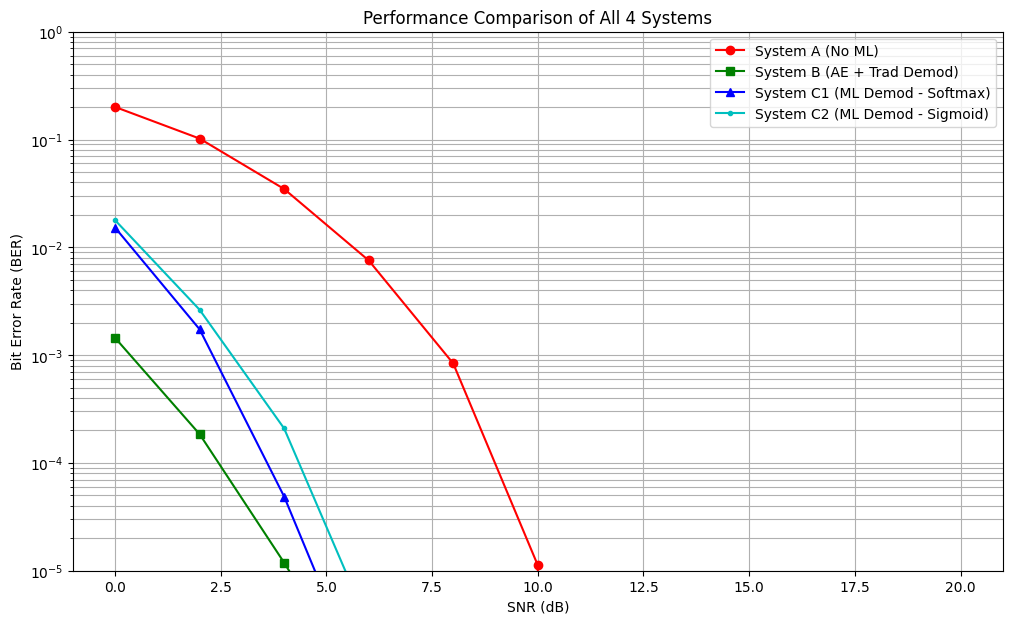


--- ı‰ Explanation of Loss Functions ---

You used three different loss functions in this project, each for a specific job:

1.  **Mean Squared Error (`mean_squared_error`)**
    * **Used By:** System B (The Autoencoder).
    * **What it does:** This is a **REGRESSION** loss. It compares the model's output (the "cleaned" signal) to the target (the "perfect" signal) *sample by sample*. It calculates the squared difference between them and tries to get this difference to zero.
    * **Analogy:** It's like a game of "hot and cold." It tells the model *how far away* its guess is from the real value.

2.  **Categorical Cross-Entropy (`categorical_crossentropy`)**
    * **Used By:** System C1 (The Softmax Demodulator).
    * **What it does:** This is a **CLASSIFICATION** loss. It's designed to work with a `softmax` output, which gives a probability for *every* class (e.g., `[P(0), P(1)]` -> `[0.1, 0.9]`).
    * **Analogy:** It's like a multiple-choice quiz. It gives a high penalty for being

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
Calculating frequencies for eye diagrams...


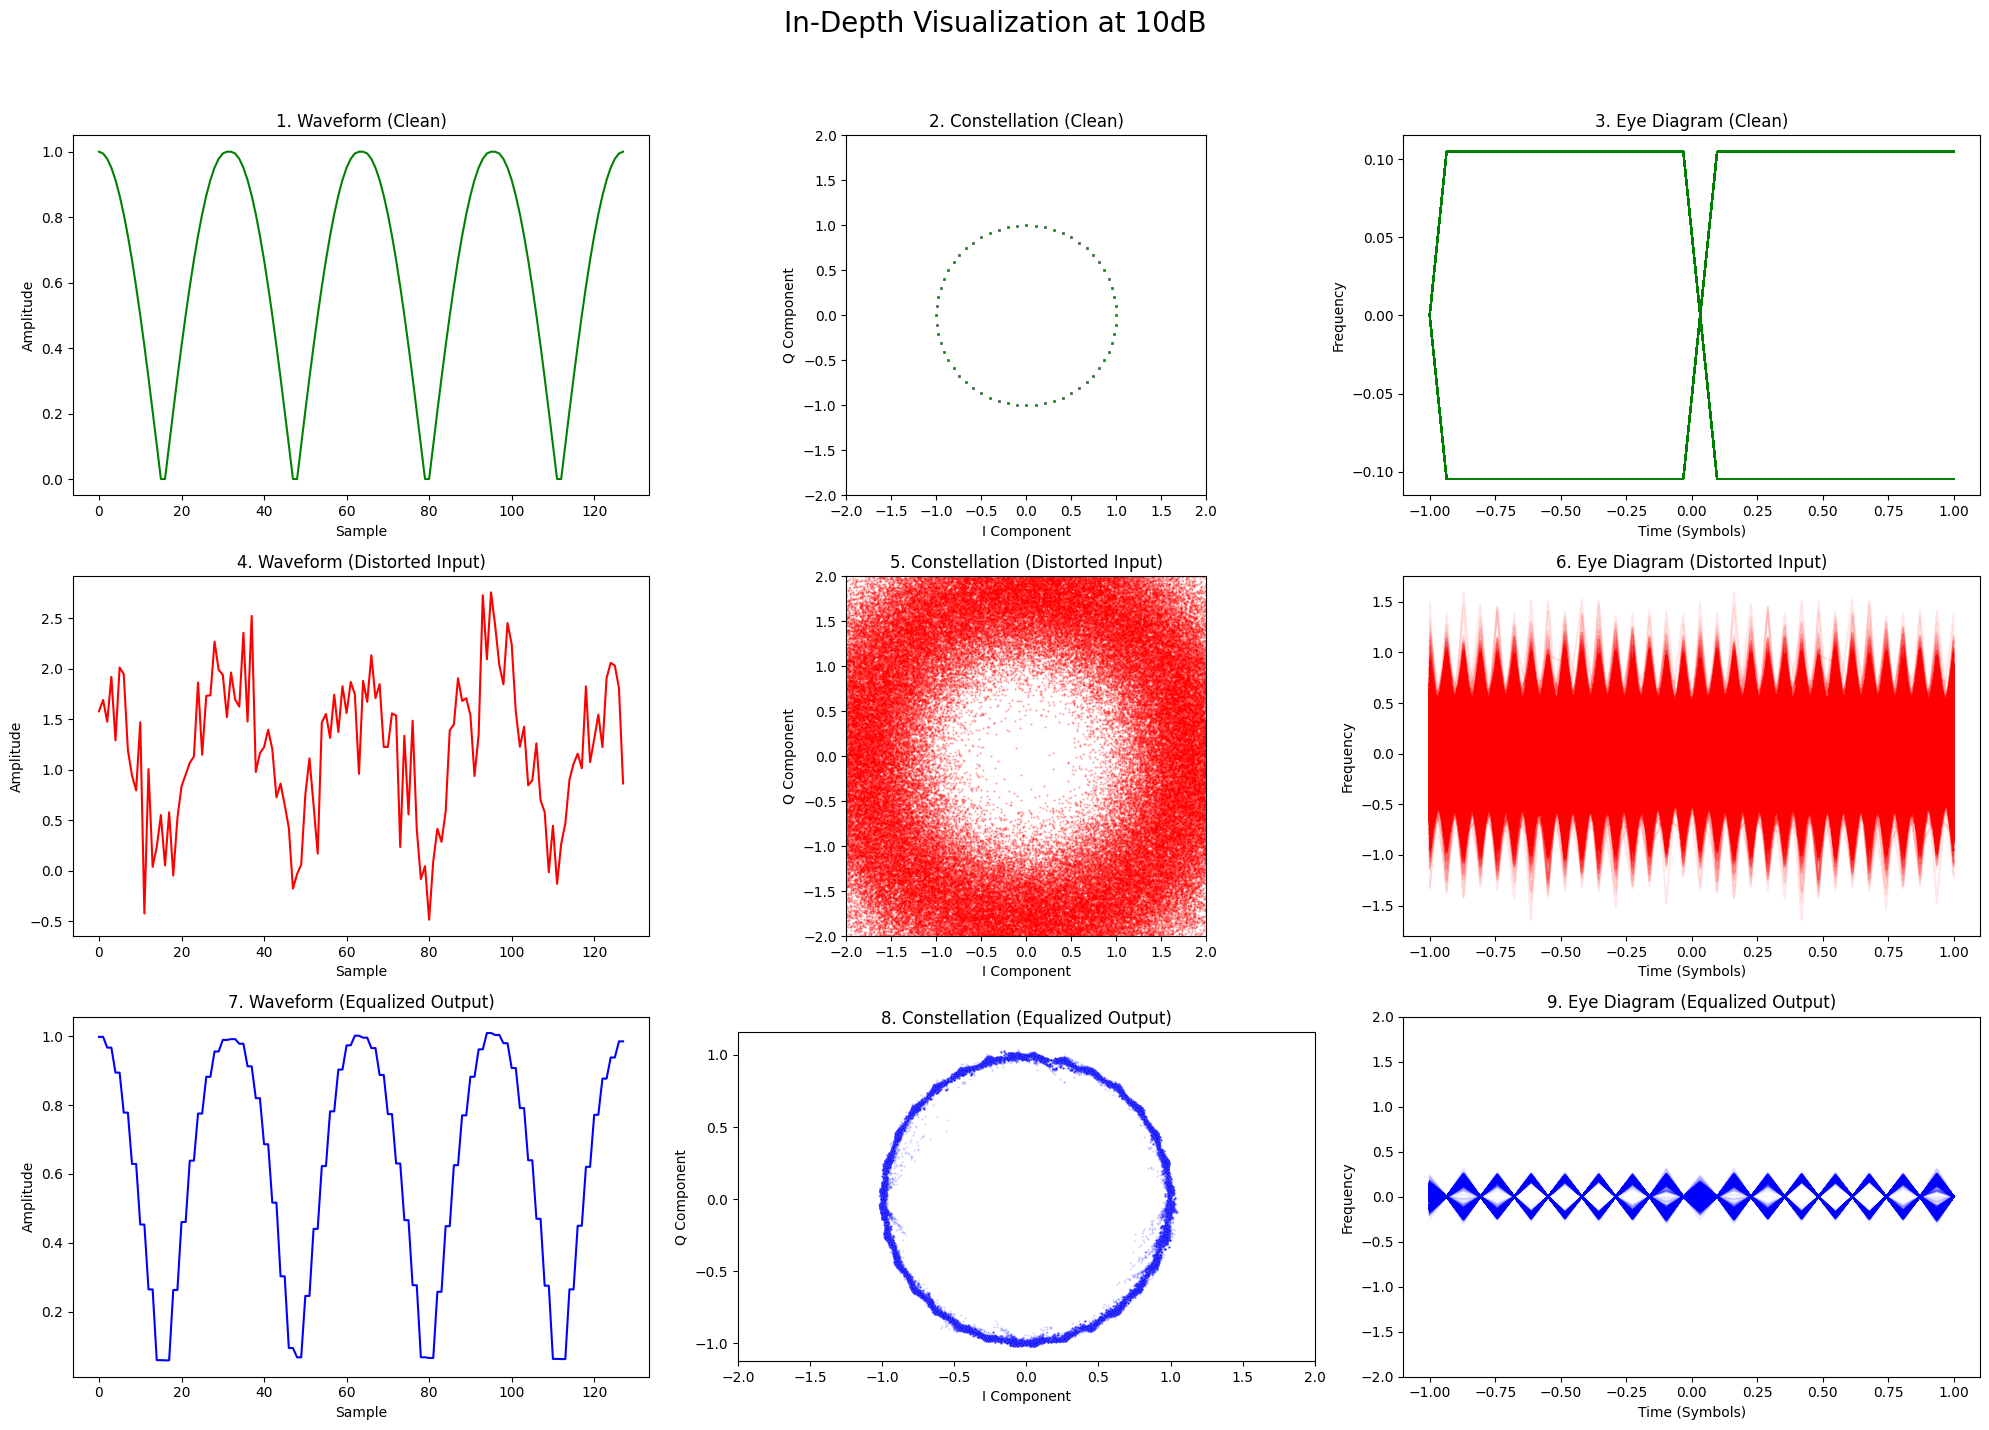

✅ Visualization complete and memory cleared.


In [ ]:
# --- 1. PLOT THE FINAL BER CURVE ---
print("Plotting final BER comparison curve...")

plt.figure(figsize=(12, 7))
plt.semilogy(SNR_RANGE_DB, ber_results["A (No ML)"], 'ro-', label='System A (No ML)')
plt.semilogy(SNR_RANGE_DB, ber_results["B (AE + Trad)"], 'gs-', label='System B (AE + Trad Demod)')
plt.semilogy(SNR_RANGE_DB, ber_results["C1 (Softmax)"], 'b^-', label='System C1 (ML Demod - Softmax)')
plt.semilogy(SNR_RANGE_DB, ber_results["C2 (Sigmoid)"], 'c.-', label='System C2 (ML Demod - Sigmoid)')
plt.grid(True, which='both')
plt.xlabel('SNR (dB)')
plt.ylabel('Bit Error Rate (BER)')
plt.title('Performance Comparison of All 4 Systems')
plt.legend()
plt.ylim(1e-5, 1.0)
plt.show()

# --- 2. EXPLANATION OF LOSS FUNCTIONS ---
print("\n--- ı‰ Explanation of Loss Functions ---")
print(f"""
You used three different loss functions in this project, each for a specific job:

1.  **Mean Squared Error (`mean_squared_error`)**
    * **Used By:** System B (The Autoencoder).
    * **What it does:** This is a **REGRESSION** loss. It compares the model's output (the "cleaned" signal) to the target (the "perfect" signal) *sample by sample*. It calculates the squared difference between them and tries to get this difference to zero.
    * **Analogy:** It's like a game of "hot and cold." It tells the model *how far away* its guess is from the real value.

2.  **Categorical Cross-Entropy (`categorical_crossentropy`)**
    * **Used By:** System C1 (The Softmax Demodulator).
    * **What it does:** This is a **CLASSIFICATION** loss. It's designed to work with a `softmax` output, which gives a probability for *every* class (e.g., `[P(0), P(1)]` -> `[0.1, 0.9]`).
    * **Analogy:** It's like a multiple-choice quiz. It gives a high penalty for being "confidently wrong" (e.g., predicting `[0.9, 0.1]` when the answer is `1`) and a low penalty for being "confidently right."

3.  **Binary Cross-Entropy (`binary_crossentropy`)**
    * **Used By:** System C2 (The Sigmoid Demodulator).
    * **What it does:** This is also a **CLASSIFICATION** loss, but it's *specialized* for only two classes. It's designed to work with a `sigmoid` output, which gives a *single* probability (e.g., `0.9` meaning 90% chance it's a '1').
    * **Analogy:** It's like a True/False quiz. As we did in the math example, it's mathematically equivalent to Categorical Cross-Entropy *when you only have two classes*.
""")

# --- 3. NEW: IN-DEPTH VISUALIZATION at 10dB ---
print("\n--- ı‰ In-Depth Visualization at 10dB ---")
print("Re-running test at 10dB to generate plots...")
print("Note: We can only visualize signals. Systems C1/C2 output BITS, so they are not shown here.")

# --- 3. NEW: IN-DEPTH VISUALIZATION at 10dB ---
print("\n--- 💡 In-Depth Visualization at 10dB ---")
print("Re-running test at 10dB to generate plots...")
print("Note: We can only visualize signals. Systems C1/C2 output BITS, so they are not shown here.")

# --- 3a. Generate the data for 10dB ---
VIS_SNR = 10
VIS_BITS = 10000 # Just need a few bits for good plots
vis_test_bits = np.random.randint(0, 2, VIS_BITS)
vis_clean_test = generate_cpfsk(vis_test_bits, SPS, H)
vis_distorted_test = apply_multipath_channel(vis_clean_test, CHANNEL_TAPS)
vis_noisy_distorted_test = add_noise(vis_distorted_test, VIS_SNR)

# Create windowed test data
X_vis, Y_vis = create_windowed_dataset(
    vis_clean_test, vis_noisy_distorted_test, WINDOW_SIZE, STEP_SIZE
)

# --- 3b. Run the Autoencoder (System B) ---
autoencoder = load_model("autoencoder.h5")
X_equalized_vis = autoencoder.predict(X_vis, batch_size=512)

# --- 3c. Get the signals for plotting ---
# We need the 1D frequency data for the Eye Diagram
print("Calculating frequencies for eye diagrams...")
freq_clean = get_inst_frequency(Y_vis)
freq_distorted = get_inst_frequency(X_vis)
freq_equalized = get_inst_frequency(X_equalized_vis)

# --- 3d. Create the 3x3 Plot Grid ---
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
plt.suptitle(f'In-Depth Visualization at {VIS_SNR}dB', fontsize=20)

# --- Row 1: Original Clean Signal (The Target) ---
axes[0, 0].plot(Y_vis[0, :, 0], 'g-') # Plot I-channel of first window
axes[0, 0].set_title('1. Waveform (Clean)')
axes[0, 0].set_xlabel('Sample'); axes[0, 0].set_ylabel('Amplitude')

sns.scatterplot(x=Y_vis[..., 0].flatten(), y=Y_vis[..., 1].flatten(), alpha=0.1, s=2, ax=axes[0, 1], color='green')
axes[0, 1].set_title('2. Constellation (Clean)')
axes[0, 1].set_xlabel('I Component'); axes[0, 1].set_ylabel('Q Component')
axes[0, 1].axis('square'); axes[0, 1].set_xlim(-2, 2); axes[0, 1].set_ylim(-2, 2)

# --- Eye Diagram (Clean) ---
eye_length_vis = 2 * SPS
t_vis = np.linspace(-1, 1, eye_length_vis)
num_segments_vis = len(freq_clean) // SPS - 2
for i in range(num_segments_vis):
    start = i * SPS
    end = start + eye_length_vis
    if end >= len(freq_clean): break
    axes[0, 2].plot(t_vis, freq_clean[start:end], 'g-', alpha=0.01) # Reduced alpha
axes[0, 2].set_title('3. Eye Diagram (Clean)')
axes[0, 2].set_xlabel('Time (Symbols)'); axes[0, 2].set_ylabel('Frequency')


# --- Row 2: Distorted Signal (Input to all systems) ---
axes[1, 0].plot(X_vis[0, :, 0], 'r-')
axes[1, 0].set_title('4. Waveform (Distorted Input)')
axes[1, 0].set_xlabel('Sample'); axes[1, 0].set_ylabel('Amplitude')

sns.scatterplot(x=X_vis[..., 0].flatten(), y=X_vis[..., 1].flatten(), alpha=0.05, s=2, ax=axes[1, 1], color='red')
axes[1, 1].set_title('5. Constellation (Distorted Input)')
axes[1, 1].set_xlabel('I Component'); axes[1, 1].set_ylabel('Q Component')
axes[1, 1].axis('square'); axes[1, 1].set_xlim(-2, 2); axes[1, 1].set_ylim(-2, 2)

# --- Eye Diagram (Distorted) ---
num_segments_vis = len(freq_distorted) // SPS - 2
for i in range(num_segments_vis):
    start = i * SPS
    end = start + eye_length_vis
    if end >= len(freq_distorted): break
    axes[1, 2].plot(t_vis, freq_distorted[start:end], 'r-', alpha=0.01) # Reduced alpha
axes[1, 2].set_title('6. Eye Diagram (Distorted Input)')
axes[1, 2].set_xlabel('Time (Symbols)'); axes[1, 2].set_ylabel('Frequency')


# --- Row 3: Equalized Signal (Output of System B) ---
axes[2, 0].plot(X_equalized_vis[0, :, 0], 'b-')
axes[2, 0].set_title('7. Waveform (Equalized Output)')
axes[2, 0].set_xlabel('Sample'); axes[2, 0].set_ylabel('Amplitude')

sns.scatterplot(x=X_equalized_vis[..., 0].flatten(), y=X_equalized_vis[..., 1].flatten(), alpha=0.1, s=2, ax=axes[2, 1], color='blue')
axes[2, 1].set_title('8. Constellation (Equalized Output)')
axes[2, 1].set_xlabel('I Component'); axes[2, 1].set_ylabel('Q Component')
axes[2, 1].axis('square'); axes[2, 1].set_xlim(-2, 2); axes[2, 2].set_ylim(-2, 2)

# --- Eye Diagram (Equalized) ---
num_segments_vis = len(freq_equalized) // SPS - 2
for i in range(num_segments_vis):
    start = i * SPS
    end = start + eye_length_vis
    if end >= len(freq_equalized): break
    axes[2, 2].plot(t_vis, freq_equalized[start:end], 'b-', alpha=0.01) # Reduced alpha
axes[2, 2].set_title('9. Eye Diagram (Equalized Output)')
axes[2, 2].set_xlabel('Time (Symbols)'); axes[2, 2].set_ylabel('Frequency')


plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()

# Clean up
del vis_test_bits, vis_clean_test, vis_distorted_test, vis_noisy_distorted_test
del X_vis, Y_vis, autoencoder, X_equalized_vis
del freq_clean, freq_distorted, freq_equalized
gc.collect()

print("✅ Visualization complete and memory cleared.")


✅ Helper functions loaded.
TESTING on new unseen Channel B: [0.8, 0.1j, (0.5-0.1j), 0, 0.2]
Using model parameters: SPS=16, WindowSize=128
Loading all three trained models (trained on Channel A)...
✅ All models loaded successfully.

--- Starting BER Evaluation Loop (Surprise Test) ---
--- Testing SNR: 0 dB ---
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
  BER [A]:  0.200130
  BER [B]:  0.001318
  BER [C1]: 0.016014
  BER [C2]: 0.018818
--- Testing SNR: 2 dB ---
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
  BER [A]:  0.101913
  BER [B]:  0.000151
  BER [C1]: 0.001785
  BER [C2]: 0.003076
--- Testing SNR: 4 dB ---
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
  BER [A]:  0.036143
  BER [B]:  0.000006
  BER [C1]: 0.000084
  BER [C2]: 0.000231
--- Testing SNR

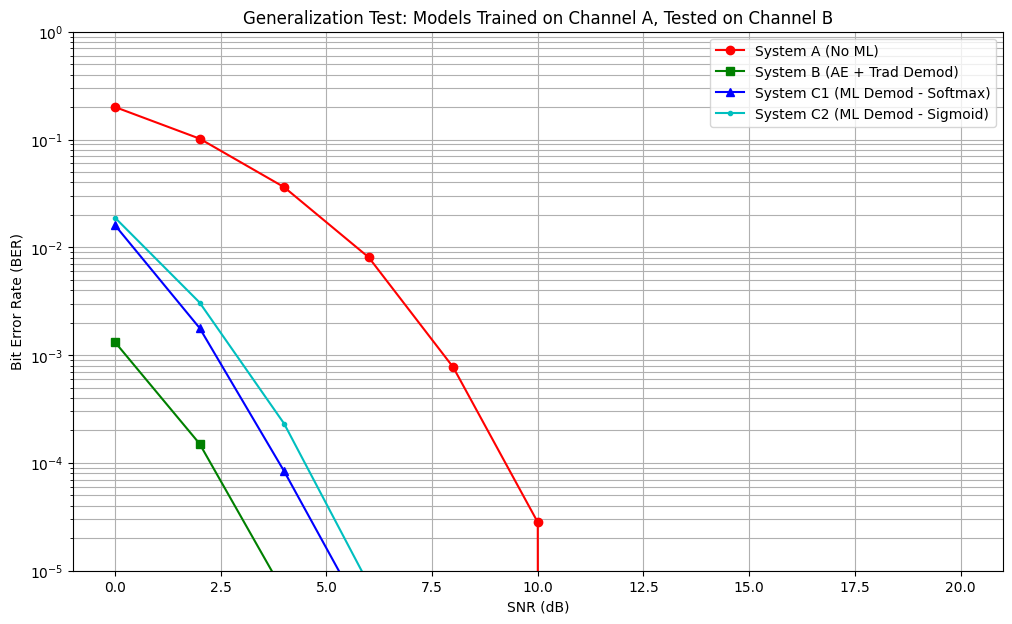

✅ All tasks complete.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical
import gc
import os # Added to check if files exist

# =============================================================================
# ### 1. ALL HELPER FUNCTIONS (Needed for testing)
# =============================================================================

def generate_cpfsk(data_bits, sps=16, h=0.5):
    """Generates a clean complex CPFSK signal."""
    symbols = data_bits * 2 - 1
    num_symbols = len(symbols)
    phase_per_symbol = np.pi * h
    symbol_phase_ramp = np.linspace(0, phase_per_symbol, sps)
    current_phase = 0
    phase_signal = np.zeros(num_symbols * sps)
    for i in range(num_symbols):
        phase_ramp = symbol_phase_ramp * symbols[i]
        start_idx = i * sps; end_idx = (i + 1) * sps
        phase_signal[start_idx : end_idx] = current_phase + phase_ramp
        current_phase = phase_signal[end_idx - 1]
    return np.exp(1j * phase_signal)

def apply_multipath_channel(signal, taps):
    """Applies multipath and ISI by convolving the signal with channel taps."""
    return convolve(signal, taps, mode='same')

def add_noise(signal, snr_db):
    """Adds Additive White Gaussian Noise (AWGN) to a complex signal."""
    signal_power = np.mean(np.abs(signal)**2)
    snr_linear = 10**(snr_db / 10.0)
    noise_power = signal_power / snr_linear
    noise = (np.random.randn(len(signal)) + 1j * np.random.randn(len(signal))) * \
            np.sqrt(noise_power / 2)
    return signal + noise

def create_windowed_dataset(clean_signal, distorted_signal, window_size=128, step=16):
    """Creates the (X, Y) dataset for the autoencoder."""
    X_windows, Y_windows = [], []
    for i in range(0, len(clean_signal) - window_size, step):
        dist_window = distorted_signal[i : i + window_size]
        clean_window = clean_signal[i : i + window_size]
        X_windows.append(np.vstack([np.real(dist_window), np.imag(dist_window)]).T)
        Y_windows.append(np.vstack([np.real(clean_window), np.imag(clean_window)]).T)
    return np.array(X_windows), np.array(Y_windows)

def traditional_demodulator(signal_windows, sps):
    """Demodulates windowed CPFSK signals using a simple frequency discriminator."""
    complex_windows = signal_windows[..., 0] + 1j * signal_windows[..., 1]
    num_windows, window_size = complex_windows.shape
    num_bits_per_window = window_size // sps
    demod_bits_all = np.zeros((num_windows, num_bits_per_window), dtype=int)
    for i in range(num_windows):
        window = complex_windows[i, :]
        phase = np.unwrap(np.angle(window))
        freq = np.diff(phase, prepend=phase[0])
        try:
            freq_blocks = freq.reshape((num_bits_per_window, sps))
            avg_freq_per_bit = np.mean(freq_blocks, axis=1)
            demod_bits = (avg_freq_per_bit > 0).astype(int)
            demod_bits_all[i, :] = demod_bits
        except ValueError: continue
    return demod_bits_all

def create_truth_bit_windows(data_bits, num_windows, window_size, sps):
    """Creates the 'ground truth' bit windows (N, 4)."""
    num_bits_per_window = window_size // sps # Will be 128 // 32 = 4
    truth_bits_windowed = np.zeros((num_windows, num_bits_per_window), dtype=int)
    for i in range(num_windows):
        start_bit = i; end_bit = i + num_bits_per_window
        if end_bit > len(data_bits): break
        truth_bits_windowed[i, :] = data_bits[start_bit : end_bit]
    return truth_bits_windowed

print("✅ Helper functions loaded.")

# =============================================================================
# ### 2. DEFINE TEST PARAMETERS
# =============================================================================
# --- Model & Signal Parameters (Must match training) ---
SPS = 16 # Changed from 32 to 16 to match training
WINDOW_SIZE = 128
STEP_SIZE = SPS # Changed to match SPS
H = 0.5

# --- Test Parameters ---
NUM_BITS_TEST = 200000
SNR_RANGE_DB = np.arange(0, 21, 2)

# --- ⚠  NEW CHANNEL FOR TESTING ⚠ ---
CHANNEL_TAPS_TEST = [0.8, 0.1j, 0.5-0.1j, 0, 0.2] # <--- Channel B
print(f"TESTING on new unseen Channel B: {CHANNEL_TAPS_TEST}")
print(f"Using model parameters: SPS={SPS}, WindowSize={WINDOW_SIZE}")

# =============================================================================
# ### 3. LOAD TRAINED MODELS
# =============================================================================
print("Loading all three trained models (trained on Channel A)...")

model_files = [
    "autoencoder.h5",
    "cnn_demodulator_softmax.h5",
    "cnn_demodulator_sigmoid.h5"
]
models_found = True

# Check if files exist before trying to load them
for f in model_files:
    if not os.path.exists(f):
        print(f"🚨 ERROR: Model file not found: {f}")
        print("Please make sure your trained models are present in the Colab session.")
        models_found = False

if models_found:
    autoencoder = load_model("autoencoder.h5")
    cnn_demod_softmax = load_model("cnn_demodulator_softmax.h5")
    cnn_demod_sigmoid = load_model("cnn_demodulator_sigmoid.h5")
    print("✅ All models loaded successfully.")
else:
    print("Stopping script. Please re-run your training or upload models.")

# =============================================================================
# ### 4. RUN BER EVALUATION (Surprise Test)
# =============================================================================
if models_found:
    print("\n--- Starting BER Evaluation Loop (Surprise Test) ---")

    # --- Prepare to Store Results ---
    ber_results = {
        "A (No ML)": [],
        "B (AE + Trad)": [],
        "C1 (Softmax)": [],
        "C2 (Sigmoid)": []
    }

    # --- Run Loop ---
    for snr_db in SNR_RANGE_DB:
        print(f"--- Testing SNR: {snr_db} dB ---")

        # 1. Generate new, unseen test data using CHANNEL B
        test_bits = np.random.randint(0, 2, NUM_BITS_TEST)
        clean_test = generate_cpfsk(test_bits, SPS, H)
        distorted_test = apply_multipath_channel(clean_test, CHANNEL_TAPS_TEST) # <-- Use Channel B
        noisy_distorted_test = add_noise(distorted_test, snr_db)

        # 2. Create windowed test data
        X_test, Y_test = create_windowed_dataset(
            clean_test, noisy_distorted_test, WINDOW_SIZE, STEP_SIZE
        )

        # 3. Get corresponding 'truth' bits
        num_windows = X_test.shape[0]
        truth_bits = create_truth_bit_windows(test_bits, num_windows, WINDOW_SIZE, SPS)
        total_bits = truth_bits.size

        # --- 4. TEST ALL 4 SYSTEMS ---

        # System A: Traditional Demodulator
        demod_bits_a = traditional_demodulator(X_test, SPS)
        errors_a = np.sum(demod_bits_a != truth_bits)
        ber_results["A (No ML)"].append(errors_a / total_bits)

        # System B: Autoencoder (Trained on A) + Trad Demod
        X_equalized = autoencoder.predict(X_test, batch_size=512)
        demod_bits_b = traditional_demodulator(X_equalized, SPS)
        errors_b = np.sum(demod_bits_b != truth_bits)
        ber_results["B (AE + Trad)"].append(errors_b / total_bits)

        # System C1: Softmax Demodulator (Trained on A)
        pred_prob_c1 = cnn_demod_softmax.predict(X_test, batch_size=512)
        demod_bits_c1 = np.argmax(pred_prob_c1, axis=2)
        errors_c1 = np.sum(demod_bits_c1 != truth_bits)
        ber_results["C1 (Softmax)"].append(errors_c1 / total_bits)

        # System C2: Sigmoid Demodulator (Trained on A)
        pred_prob_c2 = cnn_demod_sigmoid.predict(X_test, batch_size=512)
        demod_bits_c2 = (pred_prob_c2 > 0.5).astype(int)
        demod_bits_c2 = np.squeeze(demod_bits_c2)
        errors_c2 = np.sum(demod_bits_c2 != truth_bits)
        ber_results["C2 (Sigmoid)"].append(errors_c2 / total_bits)

        print(f"  BER [A]:  {ber_results['A (No ML)'][-1]:.6f}")
        print(f"  BER [B]:  {ber_results['B (AE + Trad)'][-1]:.6f}")
        print(f"  BER [C1]: {ber_results['C1 (Softmax)'][-1]:.6f}")
        print(f"  BER [C2]: {ber_results['C2 (Sigmoid)'][-1]:.6f}")

        # Clean up RAM
        del test_bits, clean_test, distorted_test, noisy_distorted_test, X_test, Y_test
        del demod_bits_a, X_equalized, demod_bits_b
        del pred_prob_c1, demod_bits_c1, pred_prob_c2, demod_bits_c2
        gc.collect()

    print("✅ BER evaluation complete.")

    # =========================================================================
    # ### 5. PLOT FINAL BER CURVE
    # =========================================================================
    print("Plotting final BER comparison curve...")

    plt.figure(figsize=(12, 7))
    plt.semilogy(SNR_RANGE_DB, ber_results["A (No ML)"], 'ro-', label='System A (No ML)')
    plt.semilogy(SNR_RANGE_DB, ber_results["B (AE + Trad)"], 'gs-', label='System B (AE + Trad Demod)')
    plt.semilogy(SNR_RANGE_DB, ber_results["C1 (Softmax)"], 'b^-', label='System C1 (ML Demod - Softmax)')
    plt.semilogy(SNR_RANGE_DB, ber_results["C2 (Sigmoid)"], 'c.-', label='System C2 (ML Demod - Sigmoid)')
    plt.grid(True, which='both')
    plt.xlabel('SNR (dB)')
    plt.ylabel('Bit Error Rate (BER)')
    plt.title('Generalization Test: Models Trained on Channel A, Tested on Channel B')
    plt.legend()
    plt.ylim(1e-5, 1.0)
    plt.show()

    print("✅ All tasks complete.")